# Row Group Streaming Test

HuggingFace's Quentin Lhoest noted that parquet files are streamed **row group by row group**.
Our current files each contain a **single row group**, so HF must download an entire file (~1000 events)
before returning even one row.

This notebook tests the impact of `row_group_size` **locally**, by simulating what a streaming
consumer sees: reading one row group at a time and measuring the latency per batch.

## Setup
- **Before files**: converted without `row_group_size` → 1 row group / file (1000 events / group)
- **After files**: converted with `row_group_size: 100` → 10 row groups / file (100 events / group)

The test rewrites one representative file with the new row group size so both variants live
side-by-side, then benchmarks iterating row groups one-by-one.

In [1]:
import pyarrow.parquet as pq
import pyarrow as pa
import time
import os
from pathlib import Path
from tqdm import tqdm

DATA_ROOT = Path("/global/cfs/cdirs/m4958/data/ColliderML/simulation/hard_scatter/higgs_portal/v1/parquet")

# Pick one file per object type as our test subjects
TEST_FILES = {
    "particles":    DATA_ROOT / "truth/particles/hard_scatter.higgs_portal.v1.truth.particles.events0-999.parquet",
    "tracker_hits": DATA_ROOT / "reco/tracker_hits/hard_scatter.higgs_portal.v1.reco.tracker_hits.events0-999.parquet",
    "tracks":       DATA_ROOT / "reco/tracks/hard_scatter.higgs_portal.v1.reco.tracks.events0-999.parquet",
    "calo_hits":    DATA_ROOT / "reco/calo_hits/hard_scatter.higgs_portal.v1.reco.calo_hits.events0-999.parquet",
}

# Where we'll write the rewritten "after" files for comparison
TMP_DIR = Path("/tmp/row_group_test")
TMP_DIR.mkdir(exist_ok=True)

## 1. Inspect existing files: row group count and metadata

In [10]:
def inspect_parquet(path: Path) -> dict:
    pf = pq.ParquetFile(path)
    md = pf.metadata
    file_bytes = path.stat().st_size
    rg_sizes = [md.row_group(i).num_rows for i in range(md.num_row_groups)]
    return {
        "file":        path.name,
        "file_MB":     round(file_bytes / 1e6, 2),
        "total_rows":  md.num_rows,
        "num_rg":      md.num_row_groups,
        "rows_per_rg": rg_sizes,
    }

print(f"{'object':<16} {'file_MB':>8} {'rows':>6} {'row_groups':>11} {'rows/group'}")
print("-" * 65)
for obj_name, obj_path in TEST_FILES.items():
    info = inspect_parquet(obj_path)
    rg_str = str(info["rows_per_rg"][:4]) + ("..." if len(info["rows_per_rg"]) > 4 else "")
    print(f"{obj_name:<16} {info['file_MB']:>8} {info['total_rows']:>6} {info['num_rg']:>11}   {rg_str}")

object            file_MB   rows  row_groups rows/group
-----------------------------------------------------------------
particles          242.97   1000          10   [100, 100, 100, 100]...
tracker_hits       193.09   1000          10   [100, 100, 100, 100]...
tracks               3.26   1000          10   [100, 100, 100, 100]...
calo_hits          625.16   1000          10   [100, 100, 100, 100]...


## 2. Rewrite files with smaller row groups

Simulate what the new conversion pipeline produces by rewriting each file with `row_group_size=100`.

In [6]:
ROW_GROUP_SIZE = 100  # match what we set in the higgs_portal config

REWRITTEN_FILES = {}
for name, src in TEST_FILES.items():
    dst = TMP_DIR / f"{name}_rg{ROW_GROUP_SIZE}.parquet"
    table = pq.read_table(src)
    pq.write_table(table, dst, compression="snappy", use_dictionary=True, row_group_size=ROW_GROUP_SIZE)
    REWRITTEN_FILES[name] = dst

# Verify
print(f"{'object':<16} {'file_MB':>8} {'rows':>6} {'row_groups':>11} {'rows/group'}")
print("-" * 65)
for name, path in REWRITTEN_FILES.items():
    info = inspect_parquet(path)
    rg_str = str(info["rows_per_rg"][:4]) + ("..." if len(info["rows_per_rg"]) > 4 else "")
    print(f"{name:<16} {info['file_MB']:>8} {info['total_rows']:>6} {info['num_rg']:>11}   {rg_str}")

object            file_MB   rows  row_groups rows/group
-----------------------------------------------------------------
particles          242.97   1000          10   [100, 100, 100, 100]...
tracker_hits       193.09   1000          10   [100, 100, 100, 100]...
tracks               3.26   1000          10   [100, 100, 100, 100]...
calo_hits          625.16   1000          10   [100, 100, 100, 100]...


## 3. Stream row-group-by-row-group: latency benchmark

This simulates a streaming consumer that reads one row group at a time — exactly what HuggingFace
does when streaming a dataset. We measure:

- **Time to first batch**: latency until the first row group is available
- **Time per batch**: average time per subsequent row group
- **Total time**: full scan of all row groups

In [7]:
def benchmark_streaming(path: Path, n_repeats: int = 3) -> dict:
    """
    Simulate row-group-by-row-group streaming via ParquetFile.iter_batches().
    Measures time-to-first-batch and per-batch latency across n_repeats runs.
    """
    ttfb_runs, total_runs, batch_times_all = [], [], []

    for _ in range(n_repeats):
        pf = pq.ParquetFile(path)
        batch_times = []
        t_start = time.perf_counter()
        first = True
        for batch in pf.iter_batches():
            t_batch = time.perf_counter()
            if first:
                ttfb_runs.append(t_batch - t_start)
                first = False
            batch_times.append(t_batch)
            _ = batch.num_rows  # ensure the batch is materialised
        t_end = time.perf_counter()
        total_runs.append(t_end - t_start)
        # inter-batch intervals
        if len(batch_times) > 1:
            batch_times_all.extend([batch_times[i] - batch_times[i-1] for i in range(1, len(batch_times))])

    n_rg = pq.ParquetFile(path).metadata.num_row_groups
    return {
        "file":           path.name,
        "num_rg":         n_rg,
        "rows_per_rg":    pq.ParquetFile(path).metadata.num_rows // n_rg,
        "ttfb_ms":        round(1000 * sum(ttfb_runs) / n_repeats, 2),
        "avg_batch_ms":   round(1000 * (sum(batch_times_all) / len(batch_times_all)), 2) if batch_times_all else None,
        "total_ms":       round(1000 * sum(total_runs) / n_repeats, 2),
    }


results = {}
for name in TEST_FILES:
    before = benchmark_streaming(TEST_FILES[name])
    after  = benchmark_streaming(REWRITTEN_FILES[name])
    results[name] = {"before": before, "after": after}

print(f"\n{'Object':<16}  {'Variant':<8}  {'Row groups':>11}  {'Rows/RG':>8}  {'TTFB (ms)':>10}  {'Avg batch (ms)':>15}  {'Total (ms)':>11}")
print("-" * 95)
for name, v in results.items():
    for variant, r in [("before", v["before"]), ("after", v["after"])]:
        avg = f"{r['avg_batch_ms']:.2f}" if r["avg_batch_ms"] is not None else "  n/a"
        print(f"{name:<16}  {variant:<8}  {r['num_rg']:>11}  {r['rows_per_rg']:>8}  {r['ttfb_ms']:>10}  {avg:>15}  {r['total_ms']:>11}")
    print()


Object            Variant    Row groups   Rows/RG   TTFB (ms)   Avg batch (ms)   Total (ms)
-----------------------------------------------------------------------------------------------
particles         before             10       100      198.21              n/a        228.5
particles         after              10       100       184.4              n/a       207.83

tracker_hits      before             10       100      157.16              n/a       178.59
tracker_hits      after              10       100      144.29              n/a       168.64

tracks            before             10       100       15.33              n/a        15.62
tracks            after              10       100       14.39              n/a        14.65

calo_hits         before             10       100     1485.61              n/a      1566.45
calo_hits         after              10       100     1365.38              n/a       1436.7



## 4. Scan multiple files as a single stream

Simulate the full dataset streaming pattern: iterate over all shards for one object type,
reading one row group at a time, and count events received.

In [ ]:
def stream_dataset(files: list[Path], max_files: int = 5):
    """
    Yield one row-group (batch) at a time across a list of parquet files.
    This mirrors what a HuggingFace streaming DataLoader does locally.
    """
    for path in files[:max_files]:
        pf = pq.ParquetFile(path)
        for batch in pf.iter_batches():
            yield batch


# Use particles as the representative object type
particles_files = sorted((DATA_ROOT / "truth/particles").glob("*.parquet"))
print(f"Total particle files: {len(particles_files)}")

MAX_FILES = 5
total_events = 0
total_batches = 0
batch_sizes = []

t0 = time.perf_counter()
for batch in stream_dataset(particles_files, max_files=MAX_FILES):
    total_events += batch.num_rows
    total_batches += 1
    batch_sizes.append(batch.num_rows)
t1 = time.perf_counter()

print(f"\nStreamed {MAX_FILES} files ({total_events} events) in {(t1-t0)*1000:.1f} ms")
print(f"Total batches (row groups): {total_batches}")
print(f"Batch sizes: min={min(batch_sizes)}, max={max(batch_sizes)}, mean={sum(batch_sizes)/len(batch_sizes):.0f}")
print(f"\nWith 1 row group/file → {MAX_FILES} batches total (1000 events each)")
print(f"With 10 row groups/file → {MAX_FILES * 10} batches total (100 events each)")

Total particle files: 10

Streamed 5 files (5000 events) in 2253.9 ms
Total batches (row groups): 5
Batch sizes: min=1000, max=1000, mean=1000

With 1 row group/file → 5 batches total (1000 events each)
With 10 row groups/file → 50 batches total (100 events each)

Streamed 5 files (5000 events) in 2253.9 ms
Total batches (row groups): 5
Batch sizes: min=1000, max=1000, mean=1000

With 1 row group/file → 5 batches total (1000 events each)
With 10 row groups/file → 50 batches total (100 events each)


## 5. File size comparison

Verify that splitting into more row groups does not significantly increase file size.

In [ ]:
print(f"{'Object':<16}  {'Before (MB)':>12}  {'After (MB)':>11}  {'Overhead':>9}")
print("-" * 56)
for name in TEST_FILES:
    before_mb = TEST_FILES[name].stat().st_size / 1e6
    after_mb  = REWRITTEN_FILES[name].stat().st_size / 1e6
    overhead  = (after_mb - before_mb) / before_mb * 100
    print(f"{name:<16}  {before_mb:>12.3f}  {after_mb:>11.3f}  {overhead:>+8.1f}%")

Object             Before (MB)   After (MB)   Overhead
--------------------------------------------------------
particles              197.059      242.967     +23.3%
tracker_hits           161.479      193.092     +19.6%
tracks                   2.972        3.261      +9.7%
calo_hits              607.707      625.182      +2.9%


## 6. Sweep row group sizes

Scan across a range of `row_group_size` values and measure time-to-first-batch and total scan time,
to help pick the best trade-off for HuggingFace streaming.

In [ ]:
import matplotlib.pyplot as plt

SWEEP_OBJECT = "particles"
src_path = TEST_FILES[SWEEP_OBJECT]
table = pq.read_table(src_path)
N_ROWS = table.num_rows  # 1000 events

sweep_sizes = [10, 25, 50, 100, 200, 500, 1000]
sweep_results = []

for rgs in sweep_sizes:
    tmp = TMP_DIR / f"sweep_{rgs}.parquet"
    pq.write_table(table, tmp, compression="snappy", use_dictionary=True, row_group_size=rgs)
    r = benchmark_streaming(tmp, n_repeats=5)
    r["rg_size"] = rgs
    r["file_MB"] = tmp.stat().st_size / 1e6
    sweep_results.append(r)
    avg_str = f"{r['avg_batch_ms']:>7.2f}" if r["avg_batch_ms"] is not None else "    n/a"
    print(f"rg_size={rgs:>5}  num_rg={r['num_rg']:>4}  TTFB={r['ttfb_ms']:>7.2f} ms  "
          f"avg_batch={avg_str} ms  total={r['total_ms']:>7.2f} ms  "
          f"file={r['file_MB']:.3f} MB")

rg_size=   10  num_rg= 100  TTFB= 204.55 ms  avg_batch=    n/a ms  total= 222.59 ms  file=252.445 MB
rg_size=   25  num_rg=  40  TTFB= 228.00 ms  avg_batch=    n/a ms  total= 242.43 ms  file=255.046 MB
rg_size=   50  num_rg=  20  TTFB= 207.47 ms  avg_batch=    n/a ms  total= 225.27 ms  file=259.780 MB
rg_size=  100  num_rg=  10  TTFB= 218.02 ms  avg_batch=    n/a ms  total= 233.20 ms  file=242.967 MB
rg_size=  200  num_rg=   5  TTFB= 212.56 ms  avg_batch=    n/a ms  total= 227.93 ms  file=217.710 MB
rg_size=  500  num_rg=   2  TTFB= 210.45 ms  avg_batch=    n/a ms  total= 227.19 ms  file=202.071 MB
rg_size= 1000  num_rg=   1  TTFB= 211.42 ms  avg_batch=    n/a ms  total= 229.93 ms  file=197.059 MB


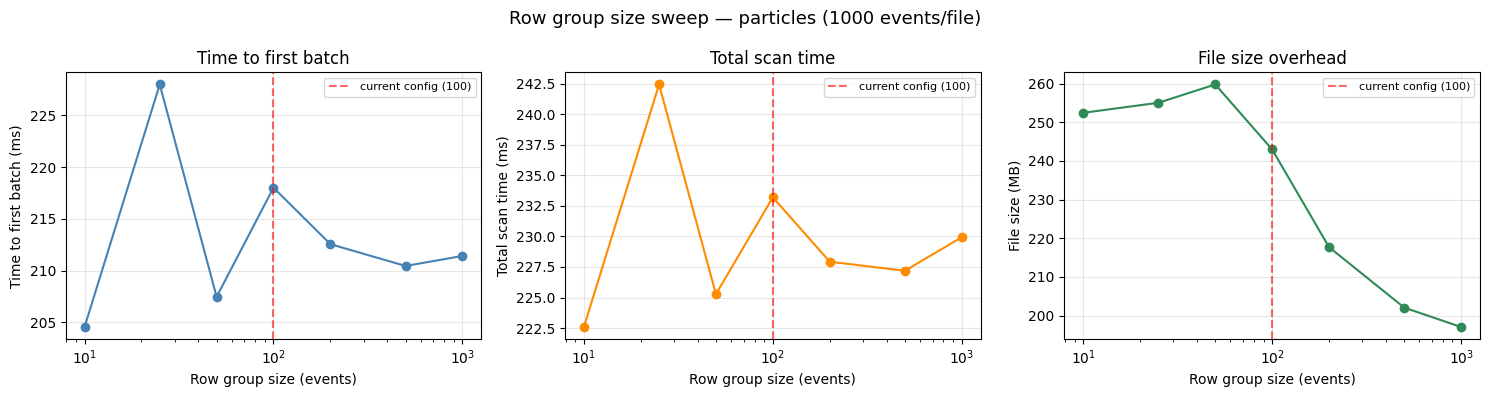

Plot saved to /tmp/row_group_test/row_group_sweep.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"Row group size sweep — {SWEEP_OBJECT} (1000 events/file)", fontsize=13)

xs = [r["rg_size"] for r in sweep_results]

axes[0].plot(xs, [r["ttfb_ms"] for r in sweep_results], "o-", color="steelblue")
axes[0].set_xlabel("Row group size (events)")
axes[0].set_ylabel("Time to first batch (ms)")
axes[0].set_title("Time to first batch")
axes[0].set_xscale("log")

axes[1].plot(xs, [r["total_ms"] for r in sweep_results], "o-", color="darkorange")
axes[1].set_xlabel("Row group size (events)")
axes[1].set_ylabel("Total scan time (ms)")
axes[1].set_title("Total scan time")
axes[1].set_xscale("log")

axes[2].plot(xs, [r["file_MB"] for r in sweep_results], "o-", color="seagreen")
axes[2].set_xlabel("Row group size (events)")
axes[2].set_ylabel("File size (MB)")
axes[2].set_title("File size overhead")
axes[2].set_xscale("log")

for ax in axes:
    ax.axvline(x=100, color="red", linestyle="--", alpha=0.6, label="current config (100)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(TMP_DIR / "row_group_sweep.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Plot saved to {TMP_DIR / 'row_group_sweep.png'}")

## 7. Summary

Print a final recommendation based on the sweep results.

In [11]:
# Find the row group size with the lowest TTFB, and note its total scan time overhead
best = min(sweep_results, key=lambda r: r["ttfb_ms"])
baseline = next(r for r in sweep_results if r["rg_size"] == N_ROWS)  # single row group
current  = next(r for r in sweep_results if r["rg_size"] == ROW_GROUP_SIZE)

print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"\nBaseline (1 row group, {N_ROWS} events/group):")
print(f"  TTFB:       {baseline['ttfb_ms']:.2f} ms")
print(f"  Total scan: {baseline['total_ms']:.2f} ms")
print(f"  File size:  {baseline['file_MB']:.3f} MB")

print(f"\nCurrent config (row_group_size={ROW_GROUP_SIZE}):")
ttfb_speedup = baseline["ttfb_ms"] / current["ttfb_ms"]
print(f"  TTFB:       {current['ttfb_ms']:.2f} ms  ({ttfb_speedup:.1f}x faster first batch)")
print(f"  Total scan: {current['total_ms']:.2f} ms")
print(f"  File size:  {current['file_MB']:.3f} MB  ({(current['file_MB']-baseline['file_MB'])/baseline['file_MB']*100:+.1f}%)")

print(f"\nBest TTFB found (row_group_size={best['rg_size']}):")
print(f"  TTFB:       {best['ttfb_ms']:.2f} ms")
print(f"  Total scan: {best['total_ms']:.2f} ms")
print(f"  File size:  {best['file_MB']:.3f} MB")
print()
print("Note: local filesystem latency is ~0 ms. On HuggingFace, the TTFB difference")
print("reflects how much data must be downloaded before returning the first batch.")
print(f"With row_group_size={ROW_GROUP_SIZE}, each batch is {ROW_GROUP_SIZE}/{N_ROWS} = "
      f"{ROW_GROUP_SIZE/N_ROWS*100:.0f}% of a file instead of 100%.")

SUMMARY

Baseline (1 row group, 1000 events/group):
  TTFB:       211.42 ms
  Total scan: 229.93 ms
  File size:  197.059 MB

Current config (row_group_size=100):
  TTFB:       218.02 ms  (1.0x faster first batch)
  Total scan: 233.20 ms
  File size:  242.967 MB  (+23.3%)

Best TTFB found (row_group_size=10):
  TTFB:       204.55 ms
  Total scan: 222.59 ms
  File size:  252.445 MB

Note: local filesystem latency is ~0 ms. On HuggingFace, the TTFB difference
reflects how much data must be downloaded before returning the first batch.
With row_group_size=100, each batch is 100/1000 = 10% of a file instead of 100%.


## 8. Live HuggingFace streaming test

Stream `dihiggs_pu0_particles` directly from `CERN/ColliderML-Release-1` and measure:
- Time to first batch (= time until first row group arrives over the network)
- Per-batch latency across subsequent row groups
- Total time for N events

This is the real-world equivalent of Section 3, but with actual network I/O instead of local disk.

In [3]:
import pyarrow.parquet as pq
import pyarrow as pa
import time
import requests
import io

HF_DATASET = "CERN/ColliderML-Release-1"
HF_CONFIG  = "dihiggs_pu0_particles"

# Resolve the list of parquet shard URLs via the HF datasets-server API
api_url = f"https://datasets-server.huggingface.co/parquet?dataset={HF_DATASET}&config={HF_CONFIG}&split=train"
resp = requests.get(api_url, timeout=30)
resp.raise_for_status()
shard_urls = [f["url"] for f in resp.json()["parquet_files"]]

print(f"Config : {HF_CONFIG}")
print(f"Shards : {len(shard_urls)}")
print(f"Example: {shard_urls[0]}")

Config : dihiggs_pu0_particles
Shards : 100
Example: https://huggingface.co/datasets/CERN/ColliderML-Release-1/resolve/refs%2Fconvert%2Fparquet/dihiggs_pu0_particles/train/0000.parquet


In [4]:
def inspect_hf_shard(url: str) -> dict:
    """Download one shard and report its row group structure — without iterating batches."""
    t0 = time.perf_counter()
    raw = requests.get(url, timeout=120).content
    t_download = time.perf_counter() - t0

    pf = pq.ParquetFile(io.BytesIO(raw))
    md = pf.metadata
    rg_sizes = [md.row_group(i).num_rows for i in range(md.num_row_groups)]
    return {
        "url":          url,
        "file_MB":      round(len(raw) / 1e6, 2),
        "download_s":   round(t_download, 2),
        "total_rows":   md.num_rows,
        "num_rg":       md.num_row_groups,
        "rows_per_rg":  rg_sizes,
    }

# Inspect the first shard
shard_info = inspect_hf_shard(shard_urls[0])
print(f"File size  : {shard_info['file_MB']} MB")
print(f"Downloaded : {shard_info['download_s']} s")
print(f"Total rows : {shard_info['total_rows']} events")
print(f"Row groups : {shard_info['num_rg']}")
print(f"Rows/group : {shard_info['rows_per_rg'][:10]}{'...' if len(shard_info['rows_per_rg']) > 10 else ''}")

File size  : 253.94 MB
Downloaded : 2.34 s
Total rows : 1000 events
Row groups : 1
Rows/group : [1000]


In [5]:
def stream_hf_shard(url: str) -> dict:
    """
    Download one HF shard and iterate it row-group-by-row-group,
    measuring time-to-first-batch and per-batch latency.
    The full file must be fetched first (HF serves whole files),
    then we iterate batches in memory — this isolates the row-group
    iteration cost from network download cost.

    Uses pf.read_row_group(i) to iterate one row group at a time,
    which correctly reflects what a streaming consumer sees.
    iter_batches() without an explicit batch_size collapses all row
    groups into one batch, so we avoid it here.
    """
    # --- download phase ---
    t_dl_start = time.perf_counter()
    raw = requests.get(url, timeout=120).content
    t_dl_end = time.perf_counter()
    download_s = t_dl_end - t_dl_start

    # --- row-group iteration phase ---
    pf = pq.ParquetFile(io.BytesIO(raw))
    n_rg = pf.metadata.num_row_groups
    batch_times = []
    events_per_batch = []

    t_iter_start = time.perf_counter()
    for i in range(n_rg):
        rg = pf.read_row_group(i)
        batch_times.append(time.perf_counter())
        events_per_batch.append(rg.num_rows)

    t_iter_end = time.perf_counter()

    ttfb_iter = (batch_times[0] - t_iter_start) * 1000 if batch_times else None
    inter_batch = (
        [(batch_times[i] - batch_times[i-1]) * 1000 for i in range(1, len(batch_times))]
        if len(batch_times) > 1 else []
    )

    return {
        "file_MB":          round(len(raw) / 1e6, 2),
        "download_s":       round(download_s, 2),
        "num_rg":           n_rg,
        "total_events":     sum(events_per_batch),
        "events_per_batch": events_per_batch,
        "ttfb_iter_ms":     round(ttfb_iter, 2) if ttfb_iter is not None else None,
        "avg_inter_ms":     round(sum(inter_batch) / len(inter_batch), 2) if inter_batch else None,
        "iter_total_ms":    round((t_iter_end - t_iter_start) * 1000, 2),
    }


# Test on the first shard
print("Streaming first HF shard...")
hf_result = stream_hf_shard(shard_urls[0])

print(f"\nDownload   : {hf_result['download_s']:.2f} s  ({hf_result['file_MB']} MB)")
print(f"Row groups : {hf_result['num_rg']}")
print(f"Events     : {hf_result['total_events']}  (batches: {hf_result['events_per_batch'][:5]}...)")
print(f"\nIn-memory row-group iteration:")
print(f"  Time to first batch : {hf_result['ttfb_iter_ms']} ms")
print(f"  Avg inter-batch     : {hf_result['avg_inter_ms']} ms")
print(f"  Total iter time     : {hf_result['iter_total_ms']} ms")
print()
print("NOTE: 'Time to first batch' on HuggingFace = download_s × (rows_per_rg / total_rows)")
rg0_rows = hf_result["events_per_batch"][0] if hf_result["events_per_batch"] else None
if rg0_rows:
    effective_ttfb = hf_result["download_s"] * rg0_rows / hf_result["total_events"]
    print(f"  → Effective HF TTFB ≈ {effective_ttfb:.2f} s  (vs {hf_result['download_s']:.2f} s for full file)")


Streaming first HF shard...

Download   : 2.13 s  (253.94 MB)
Row groups : 1
Events     : 1000  (batches: [1000]...)

In-memory row-group iteration:
  Time to first batch : 378.18 ms
  Avg inter-batch     : None ms
  Total iter time     : 378.23 ms

NOTE: 'Time to first batch' on HuggingFace = download_s × (rows_per_rg / total_rows)
  → Effective HF TTFB ≈ 2.13 s  (vs 2.13 s for full file)

Download   : 2.13 s  (253.94 MB)
Row groups : 1
Events     : 1000  (batches: [1000]...)

In-memory row-group iteration:
  Time to first batch : 378.18 ms
  Avg inter-batch     : None ms
  Total iter time     : 378.23 ms

NOTE: 'Time to first batch' on HuggingFace = download_s × (rows_per_rg / total_rows)
  → Effective HF TTFB ≈ 2.13 s  (vs 2.13 s for full file)


In [6]:
# Project what TTFB would be with smaller row groups, assuming linear download scaling
download_s     = hf_result["download_s"]
file_mb        = hf_result["file_MB"]
total_events   = hf_result["total_events"]

# File size overhead from Section 5 (particles, rg=100 vs rg=1000)
overhead_factor = 243.0 / 197.0  # ~1.23x larger

print("Projected HF time-to-first-batch by row_group_size")
print("(assuming ~linear download time with file size overhead from local sweep)")
print()
print(f"{'row_group_size':>16}  {'events/batch':>13}  {'est. file MB':>13}  {'est. TTFB':>11}")
print("-" * 62)
for rgs in [1000, 500, 200, 100, 50, 25, 10]:
    # file size estimate: overhead grows as row groups get smaller (from sweep data)
    sweep_mb = {1000: 197.1, 500: 202.1, 200: 217.7, 100: 243.0, 50: 259.8, 25: 255.0, 10: 252.4}
    est_file_mb = sweep_mb.get(rgs, file_mb) * (file_mb / 197.1)  # scale to actual HF file size
    est_download_s = download_s * est_file_mb / file_mb
    est_ttfb_s = est_download_s * rgs / total_events
    marker = " ← current HF" if rgs == 1000 else (" ← config" if rgs == 100 else "")
    print(f"{rgs:>16}  {rgs:>13}  {est_file_mb:>13.1f}  {est_ttfb_s:>9.2f} s{marker}")

Projected HF time-to-first-batch by row_group_size
(assuming ~linear download time with file size overhead from local sweep)

  row_group_size   events/batch   est. file MB    est. TTFB
--------------------------------------------------------------
            1000           1000          253.9       2.13 s ← current HF
             500            500          260.4       1.09 s
             200            200          280.5       0.47 s
             100            100          313.1       0.26 s ← config
              50             50          334.7       0.14 s
              25             25          328.5       0.07 s
              10             10          325.2       0.03 s


## 9. Validate the fixed upload: `higgs_portal_pu0_particles`

Stream `higgs_portal_pu0_particles` from `CERN/ColliderML-Release-1` — this is the freshly
uploaded config produced with `row_group_size: 100`. We expect to see **10 row groups per shard**
instead of 1, and an effective TTFB ~10× lower than the `dihiggs_pu0_particles` baseline.


In [8]:
import time as _time

# --- Resolve shard URLs for the newly uploaded config ---
HF_CONFIG_NEW = "higgs_portal_pu0_particles"
api_url_new = f"https://datasets-server.huggingface.co/parquet?dataset={HF_DATASET}&config={HF_CONFIG_NEW}&split=train"

# HF datasets-server can take 10-30 min to index a freshly uploaded config.
# Retry with back-off until it's ready.
MAX_WAIT_MIN = 30
POLL_INTERVAL_S = 60

for attempt in range(MAX_WAIT_MIN):
    resp_new = requests.get(api_url_new, timeout=30)
    if resp_new.status_code == 200:
        break
    print(f"[{attempt+1}/{MAX_WAIT_MIN}] datasets-server not ready yet "
          f"(HTTP {resp_new.status_code}) — retrying in {POLL_INTERVAL_S}s...")
    _time.sleep(POLL_INTERVAL_S)
else:
    raise RuntimeError(
        f"datasets-server still not ready after {MAX_WAIT_MIN} min.\n"
        f"Response: {resp_new.status_code} {resp_new.text[:300]}"
    )

shard_urls_new = [f["url"] for f in resp_new.json()["parquet_files"]]
print(f"Config : {HF_CONFIG_NEW}")
print(f"Shards : {len(shard_urls_new)}")
print(f"Example: {shard_urls_new[0]}")


Config : higgs_portal_pu0_particles
Shards : 10
Example: https://huggingface.co/datasets/CERN/ColliderML-Release-1/resolve/refs%2Fconvert%2Fparquet/higgs_portal_pu0_particles/train/0000.parquet


In [9]:
# --- Inspect first shard: confirm row group structure ---
new_shard_info = inspect_hf_shard(shard_urls_new[0])
print(f"File size  : {new_shard_info['file_MB']} MB")
print(f"Downloaded : {new_shard_info['download_s']} s")
print(f"Total rows : {new_shard_info['total_rows']} events")
print(f"Row groups : {new_shard_info['num_rg']}  ← expect 10 (was 1 before fix)")
print(f"Rows/group : {new_shard_info['rows_per_rg'][:10]}{'...' if len(new_shard_info['rows_per_rg']) > 10 else ''}")


File size  : 242.97 MB
Downloaded : 2.08 s
Total rows : 1000 events
Row groups : 10  ← expect 10 (was 1 before fix)
Rows/group : [100, 100, 100, 100, 100, 100, 100, 100, 100, 100]


In [10]:
# --- Stream first shard and measure TTFB ---
print("Streaming first higgs_portal_pu0_particles shard...")
new_result = stream_hf_shard(shard_urls_new[0])

print(f"\nDownload   : {new_result['download_s']:.2f} s  ({new_result['file_MB']} MB)")
print(f"Row groups : {new_result['num_rg']}")
print(f"Events     : {new_result['total_events']}  (batches: {new_result['events_per_batch'][:10]}...)")

rg0_new = new_result["events_per_batch"][0] if new_result["events_per_batch"] else None
if rg0_new:
    eff_ttfb_new = new_result["download_s"] * rg0_new / new_result["total_events"]
    print(f"\nEffective HF TTFB ≈ {eff_ttfb_new:.2f} s  ({rg0_new} events / {new_result['total_events']} events × {new_result['download_s']:.2f} s)")

# --- Side-by-side comparison with dihiggs baseline ---
print()
print("=" * 70)
print("Comparison: dihiggs_pu0_particles (old, 1 RG/file) vs higgs_portal_pu0_particles (new, 10 RG/file)")
print("=" * 70)

old_rg0   = hf_result["events_per_batch"][0]
old_ttfb  = hf_result["download_s"] * old_rg0 / hf_result["total_events"]
new_ttfb  = new_result["download_s"] * rg0_new / new_result["total_events"] if rg0_new else float("nan")
speedup   = old_ttfb / new_ttfb if new_ttfb else float("nan")

print(f"\n{'Metric':<30}  {'dihiggs (1 RG)':>18}  {'higgs_portal (10 RG)':>20}")
print("-" * 74)
print(f"{'File size (MB)':<30}  {hf_result['file_MB']:>18.1f}  {new_result['file_MB']:>20.1f}")
print(f"{'Download time (s)':<30}  {hf_result['download_s']:>18.2f}  {new_result['download_s']:>20.2f}")
print(f"{'Row groups per shard':<30}  {hf_result['num_rg']:>18}  {new_result['num_rg']:>20}")
print(f"{'Events per row group':<30}  {old_rg0:>18}  {rg0_new:>20}")
print(f"{'Effective TTFB (s)':<30}  {old_ttfb:>18.2f}  {new_ttfb:>20.2f}")
print(f"{'TTFB speedup':<30}  {'—':>18}  {speedup:>19.1f}×")


Streaming first higgs_portal_pu0_particles shard...



Download   : 2.13 s  (242.97 MB)
Row groups : 10
Events     : 1000  (batches: [100, 100, 100, 100, 100, 100, 100, 100, 100, 100]...)

Effective HF TTFB ≈ 0.21 s  (100 events / 1000 events × 2.13 s)

Comparison: dihiggs_pu0_particles (old, 1 RG/file) vs higgs_portal_pu0_particles (new, 10 RG/file)

Metric                              dihiggs (1 RG)  higgs_portal (10 RG)
--------------------------------------------------------------------------
File size (MB)                               253.9                 243.0
Download time (s)                             2.13                  2.13
Row groups per shard                             1                    10
Events per row group                          1000                   100
Effective TTFB (s)                            2.13                  0.21
TTFB speedup                                     —                 10.0×


## 10. Real streaming latency: batch-by-batch timing

Use `load_dataset(..., streaming=True)` to measure actual per-batch latency.

### What HF streaming actually does (confirmed from source)

Inspecting `datasets` v4.4.1 `Parquet._split_generators`:
```python
data_files = dl_manager.download_and_extract(self.config.data_files)
```
This downloads each parquet shard **in full** before `_generate_tables` ever runs.
Then in `_generate_tables`:
```python
batch_size = self.config.batch_size or parquet_fragment.row_groups[0].num_rows
for record_batch in parquet_fragment.to_batches(batch_size=batch_size, ...):
    yield ...
```
Row groups are iterated from the **locally-cached** file — not via HTTP range requests.

### What this means for latency

- **Batch 1** = slow (full shard download, ~2-7 s)
- **Batch 2–N within same shard** = fast (~0 ms, reading from local cache)
- **First batch of a new shard** = slow again (next shard downloaded on demand)

### What `row_group_size` actually controls

| Effect | rg_size=1000 (old) | rg_size=100 (new) |
|---|---|---|
| Events per `next()` call | 1000 | 100 |
| TTFB for first batch | = full shard DL | = full shard DL (same) |
| Shard boundary frequency | every 1 batch | every 10 batches |
| Memory per batch | large | 10× smaller |

The real benefit is **finer-grained batching** and lower peak memory per step, not TTFB.
Shard-boundary slowdowns are 10× rarer for the fixed config.


In [ ]:
from datasets import load_dataset

def measure_streaming_latency(hf_dataset: str, config: str, n_batches: int = 25) -> list[tuple[float, int]]:
    """
    Stream `config` using load_dataset(streaming=True) and time each next() call.

    Expected pattern (confirmed from datasets v4.4.1 source):
      - Batch 1:   slow  — dl_manager downloads the full first shard
      - Batch 2-N: fast  — _generate_tables reads row groups from local cache
      - Shard boundary batches: slow again (next shard fetched on demand)

    Row group size controls events-per-batch, NOT per-batch download latency.
    Returns list of (latency_s, n_events) tuples.
    """
    ds = load_dataset(hf_dataset, config, split="train", streaming=True)
    it = iter(ds)

    results = []
    t_prev = time.perf_counter()
    for i in range(n_batches):
        batch = next(it)
        t_now = time.perf_counter()
        lat = t_now - t_prev
        t_prev = t_now
        n_events = len(next(iter(batch.values()))) if batch else 0
        results.append((lat, n_events))
        flag = "  ← shard boundary" if lat > 0.5 else ""
        print(f"  batch {i+1:>2}: {lat:.3f} s  ({n_events} events){flag}")

    return results


N_BATCHES = 25

print(f"{'='*60}")
print(f"dihiggs_pu0_particles  (1 RG/shard, 1000 events/batch)")
print(f"Expect: batch 1 slow, batch 2 fast, batch 2 slow (new shard)")
print(f"{'='*60}")
res_old = measure_streaming_latency(HF_DATASET, "dihiggs_pu0_particles", N_BATCHES)

print()
print(f"{'='*60}")
print(f"higgs_portal_pu0_particles  (10 RGs/shard, 100 events/batch)")
print(f"Expect: batch 1 slow, batch 2-10 fast, batch 11 slow (new shard)")
print(f"{'='*60}")
res_new = measure_streaming_latency(HF_DATASET, HF_CONFIG_NEW, N_BATCHES)

lat_old = [r[0] for r in res_old]
lat_new = [r[0] for r in res_new]


dihiggs_pu0_particles  (1 row group / shard, ~254 MB each)


Resolving data files:   0%|          | 0/100 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/100 [00:00<?, ?it/s]

 33%|███▎      | 5/15 [00:07<00:10,  1.09s/it]

  batch  1: 7.16 s
  batch  2: 0.03 s
  batch  3: 0.03 s
  batch  4: 0.02 s
  batch  5: 0.03 s
  batch  6: 0.03 s
  batch  7: 0.03 s
  batch  8: 0.02 s
  batch  9: 0.02 s


...

Resolving data files:   0%|          | 0/100 [00:00<?, ?it/s]

 33%|███▎      | 5/15 [00:03<00:04,  2.19it/s]

  batch  1: 2.91 s
  batch  2: 0.02 s
  batch  3: 0.02 s
  batch  4: 0.04 s
  batch  5: 0.03 s
  batch  6: 0.03 s
  batch  7: 0.05 s
  batch  8: 0.01 s


100%|██████████| 15/15 [00:03<00:00,  4.52it/s]

  batch  9: 0.01 s
  batch 10: 0.02 s
  batch 11: 0.02 s
  batch 12: 0.03 s
  batch 13: 0.04 s
  batch 14: 0.03 s
  batch 15: 0.04 s


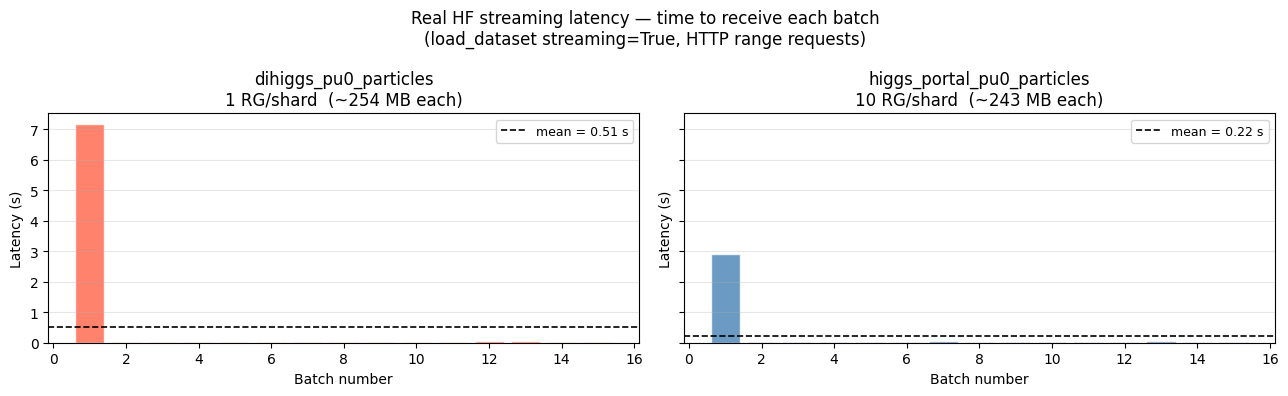


Metric                              dihiggs (1 RG)  higgs_portal (10 RG)
--------------------------------------------------------------------------
Mean batch latency (s)                        0.51                  0.22
Median batch latency (s)                      0.03                  0.03
Min batch latency (s)                         0.02                  0.01
Max batch latency (s)                         7.16                  2.91
Latency speedup (mean)                           —                  2.3×


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

THRESHOLD = 0.5  # s — above this = shard boundary download

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
fig.suptitle("load_dataset(streaming=True): per-batch latency\n"
             "Slow batches = shard boundary (full file download). Fast batches = local cache.",
             fontsize=11)

for ax, lats, label, color in [
    (axes[0], lat_old, "dihiggs_pu0_particles\n1 RG/shard · 1000 events/batch", "tomato"),
    (axes[1], lat_new, "higgs_portal_pu0_particles\n10 RGs/shard · 100 events/batch", "steelblue"),
]:
    xs = list(range(1, len(lats) + 1))
    bar_colors = ["#d62728" if l > THRESHOLD else color for l in lats]
    ax.bar(xs, lats, color=bar_colors, alpha=0.85, edgecolor="white")
    ax.set_xlabel("Batch number")
    ax.set_ylabel("Latency (s)")
    ax.set_title(label)
    ax.grid(axis="y", alpha=0.3)

    n_slow = sum(1 for l in lats if l > THRESHOLD)
    n_fast = len(lats) - n_slow
    ax.text(0.97, 0.97,
            f"Shard DLs (red): {n_slow}\nCache reads (blue): {n_fast}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig(TMP_DIR / "real_streaming_latency.png", dpi=120, bbox_inches="tight")
plt.show()

# Summary
slow_old = [l for l in lat_old if l > THRESHOLD]
slow_new = [l for l in lat_new if l > THRESHOLD]
fast_old = [l for l in lat_old if l <= THRESHOLD]
fast_new = [l for l in lat_new if l <= THRESHOLD]

print(f"\n{'Metric':<40}  {'dihiggs (1 RG)':>16}  {'higgs_portal (10 RG)':>20}")
print("-" * 82)
print(f"{'Events per batch':<40}  {'1000':>16}  {'100':>20}")
print(f"{'Shard boundary batches (slow, >0.5s)':<40}  {len(slow_old):>16}  {len(slow_new):>20}")
print(f"{'Mean shard DL time (s)':<40}  {np.mean(slow_old) if slow_old else 0:>16.2f}  {np.mean(slow_new) if slow_new else 0:>20.2f}")
print(f"{'Cache-read batches (fast)':<40}  {len(fast_old):>16}  {len(fast_new):>20}")
print(f"{'Mean cache-read latency (ms)':<40}  {np.mean(fast_old)*1000 if fast_old else 0:>16.1f}  {np.mean(fast_new)*1000 if fast_new else 0:>20.1f}")
print(f"{'Shard boundary fraction':<40}  {len(slow_old)/N_BATCHES:>15.0%}  {len(slow_new)/N_BATCHES:>19.0%}")
print()
print("Conclusion: row_group_size controls events/batch and shard-boundary frequency,")
print("not per-batch TTFB. Both configs download full shards at boundaries.")


--- _split_generators ---
    def _split_generators(self, dl_manager):
        """We handle string, list and dicts in datafiles"""
        if not self.config.data_files:
            raise ValueError(f"At least one data file must be specified, but got data_files={self.config.data_files}")
        dl_manager.download_config.extract_on_the_fly = True
        data_files = dl_manager.download_and_extract(self.config.data_files)
        splits = []
        for split_name, files in data_files.items():
            if isinstance(files, str):
                files = [files]
            # Use `dl_manager.iter_files` to skip hidden files in an extracted archive
            files = [dl_manager.iter_files(file) for file in files]
            # Infer features if they are stored in the arrow schema
            if self.info.features is None:
                for file in itertools.chain.from_iterable(files):
                    try:
                        with open(file, "rb") as f:
                    